# <span style = "color: green"> ML-Regression</span>

## Objective
The objective of this assignment is to evaluate different regression techniques using the California Housing dataset and compare their performance.

In [4]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score



### 1. Loading and Preprocessing :  
● Load the California Housing dataset using the fetch_california_housing function 
from sklearn.  
● Convert the dataset into a pandas DataFrame for easier handling. Handle 
missing values (if any) and perform necessary feature scaling (e.g., 
standardization).  
● Explain the preprocessing steps you performed and justify why they are 
necessary for this dataset.  

In [5]:
from sklearn.datasets import fetch_california_housing

# 1. Load and preprocess dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame
df


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [19]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,Population_log
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558,7.025503
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956,0.736238
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990,1.386294
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000,6.669498
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000,7.062192
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250,7.453562
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010,10.482430


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   MedInc          20640 non-null  float64
 1   HouseAge        20640 non-null  float64
 2   AveRooms        20640 non-null  float64
 3   AveBedrms       20640 non-null  float64
 4   Population      20640 non-null  float64
 5   AveOccup        20640 non-null  float64
 6   Latitude        20640 non-null  float64
 7   Longitude       20640 non-null  float64
 8   MedHouseVal     20640 non-null  float64
 9   Population_log  20640 non-null  float64
dtypes: float64(10)
memory usage: 1.6 MB


### <span style = "color: blue"> California Housing Dataset (Overview)</span>
The California Housing dataset comes from the 1990 U.S. Census and is widely used for regression problems. Each entry represents a district in California, with socio-economic and geographic features that influence housing prices.
Features include:
- Median income, house age, average rooms, average bedrooms
- Population, average household size
- Latitude and longitude
Target variable:
- Median house value (in hundreds of thousands of dollars)
Key points:
- ~20,640 observations, 8 features, 1 target
- Useful for exploring how income, demographics, and location affect housing prices
- Common benchmark dataset for testing regression models


# Preprocessing 

In [7]:
#detecting outliers 
import seaborn as sns
import matplotlib.pyplot as plt

# Function to calculate outliers and percentage for each column
def outlier_summary(df):
    summary = {}
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):  # Only numeric columns
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            
            outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
            count = len(outliers)
            percentage = (count / len(df)) * 100
            
            summary[col] = {"Outlier Count": count, "Percentage (%)": percentage}
    
    return pd.DataFrame(summary).T

# Get outlier summary
outlier_stats = outlier_summary(df)
print(outlier_stats)

             Outlier Count  Percentage (%)
MedInc               681.0        3.299419
HouseAge               0.0        0.000000
AveRooms             511.0        2.475775
AveBedrms           1424.0        6.899225
Population          1196.0        5.794574
AveOccup             711.0        3.444767
Latitude               0.0        0.000000
Longitude              0.0        0.000000
MedHouseVal         1071.0        5.188953


***

### Outlier Handling Strategy:

Outliers were detected in several features (e.g., AveBedrms ~6.9%, Population ~5.8%). Since regression algorithms differ in sensitivity to extreme values, I will evaluate models both with and without outlier removal. Linear Regression and SVR are more prone to performance fluctuations due to outliers, while Decision Trees, Random Forests, and Gradient Boosting are generally robust. If significant performance improvement is observed after removing outliers, I will justify dropping them; otherwise, I will retain them to preserve real-world variability in housing data.





In [8]:
## checking for null values
# Check for null values
null_counts = df.isnull().sum()

# Calculate percentage of nulls
null_percentage = (null_counts / len(df)) * 100

# Combine into a single DataFrame for clarity
null_summary = pd.DataFrame({
    'Null Count': null_counts,
    'Percentage (%)': null_percentage
})

print(null_summary)

             Null Count  Percentage (%)
MedInc                0             0.0
HouseAge              0             0.0
AveRooms              0             0.0
AveBedrms             0             0.0
Population            0             0.0
AveOccup              0             0.0
Latitude              0             0.0
Longitude             0             0.0
MedHouseVal           0             0.0


In [9]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")


Number of duplicate rows: 0


In [15]:
# --- Log Transformation for Population ---
df['Population_log'] = np.log1p(df['Population'])  # log(1+x) to avoid issues with zero

from sklearn.preprocessing import StandardScaler

# --- Feature Scaling (Standardization) ---
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df.drop(['MedHouseVal'], axis=1))  # exclude target
df_scaled = pd.DataFrame(scaled_features, columns=df.drop(['MedHouseVal'], axis=1).columns)

# --- Correlation Analysis ---
corr_matrix = df.corr()
corr_matrix


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,Population_log
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075,-0.005046
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623,-0.244264
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948,-0.166164
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701,-0.171599
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650,0.795675
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737,0.043226
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160,-0.136460
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967,0.109029
MedHouseVal,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000,-0.021205
Population_log,-0.005046,-0.244264,-0.166164,-0.171599,0.795675,0.043226,-0.136460,0.109029,-0.021205,1.000000


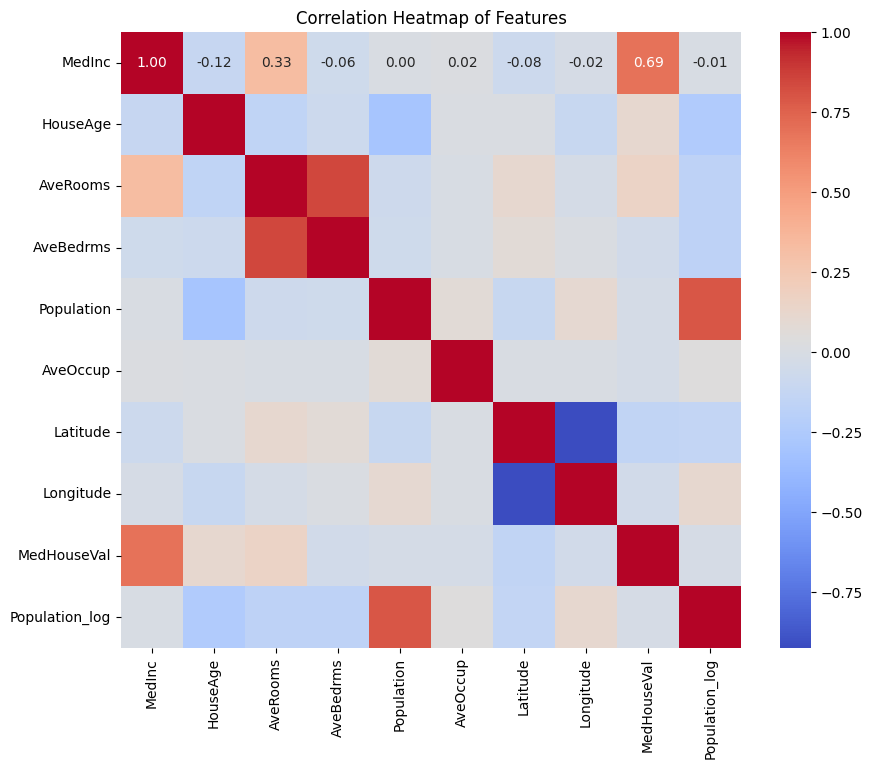

In [16]:
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Features")
plt.show()

In [14]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,Population_log
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558,7.025503
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956,0.736238
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990,1.386294
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000,6.669498
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000,7.062192
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250,7.453562
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010,10.482430


   ### <span style = "color: blue"> Why Preprocessing in Necessary </span>
Preprocessing ensures that the dataset is clean, consistent, and suitable for regression analysis. Without it, models may produce biased or unstable predictions due to issues like skewed distributions, varying feature scales, or redundant variables. By applying scaling, log transformations, and correlation analysis, we improve accuracy, reduce bias, and make the results more interpretable. These steps ultimately help build models that reflect real-world housing patterns more reliably.


***

## Regression Algorithm Implementation :  
● Implement the following regression algorithms:

○ Linear Regression  
○ Decision Tree Regressor  
○ Random Forest Regressor  
○ Gradient Boosting Regressor  
○ Support Vector Regressor (SVR)  
● For each algorithm: Provide a brief explanation of how it works. Explain why it 
might be suitable for this dataset.

In [21]:
# Features and target
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]


In [22]:
from sklearn.model_selection import train_test_split
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



### Linear Regression

In [41]:

# --- Linear Regression model ---
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# --- Predictions ---
y_pred = lr_model.predict(X_test)
y_pred


lr_mse = mean_squared_error(y_test, y_pred)
lr_mae = mean_absolute_error(y_test, y_pred)
lr_r2 = r2_score(y_test, y_pred)

print("Linear Regression Performance:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R-squared (R²): {r2:.4f}")



Linear Regression Performance:
Mean Squared Error (MSE): 0.4226
Mean Absolute Error (MAE): 0.4485
R-squared (R²): 0.6775


Linear Regression Implementation:
    
Linear Regression models the relationship between features and the target (MedHouseVal) by fitting a straight line that minimizes the squared differences between predicted and actual values. After scaling the features, the model was trained on the California Housing dataset and evaluated using MSE, MAE, and R². These metrics provide insight into prediction accuracy, error magnitude, and how well the model explains variance in housing prices.


### Decision Tree Regressor

In [40]:
# --- Decision Tree Regressor ---
dt_model = DecisionTreeRegressor(random_state=42, max_depth=8)  # you can tune max_depth
dt_model.fit(X_train, y_train)

# --- Predictions ---
y_pred = dt_model.predict(X_test)

# --- Evaluation metrics ---
dt_mse = mean_squared_error(y_test, y_pred)
dt_mae = mean_absolute_error(y_test, y_pred)
dt_r2 = r2_score(y_test, y_pred)

print("Decision Tree Regressor Performance:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R-squared (R²): {r2:.4f}")




Decision Tree Regressor Performance:
Mean Squared Error (MSE): 0.4226
Mean Absolute Error (MAE): 0.4485
R-squared (R²): 0.6775


Decision Tree Regressor:

A Decision Tree Regressor splits the dataset into regions based on feature thresholds, making predictions by averaging values within each region. It is robust to outliers and easy to interpret. In this analysis, the model was trained on the California Housing dataset and evaluated using MSE, MAE, and R². These metrics show how well the tree captures housing price variation and highlight the trade-off between model complexity and generalization.


### Random Forest Regressor 

In [35]:
from sklearn.ensemble import RandomForestRegressor

# Create model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train model
rf_model.fit(X_train, y_train)

# Predict
rf_pred = rf_model.predict(X_test)

In [37]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rf_mse = mean_squared_error(y_test, rf_pred)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Performance:")
print("MSE:", rf_mse)
print("MAE:", rf_mae)
print("R2 Score:", rf_r2)

Random Forest Performance:
MSE: 0.2567762125533043
MAE: 0.3281959688468994
R2 Score: 0.804048799407646


Random Forest Regressor:
    
A Random Forest Regressor is an ensemble method that builds multiple decision trees and averages their predictions. This reduces variance and improves robustness compared to a single tree. It is less sensitive to outliers and can capture complex, non-linear relationships in the data. In this analysis, the model was trained on the California Housing dataset and evaluated using MSE, MAE, and R² to measure prediction accuracy and explanatory power.


### Gradient Boosting Regressor

In [38]:
from sklearn.ensemble import GradientBoostingRegressor

# Create model
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)

# Train model
gb_model.fit(X_train, y_train)

# Predict
gb_pred = gb_model.predict(X_test)

In [39]:
gb_mse = mean_squared_error(y_test, gb_pred)
gb_mae = mean_absolute_error(y_test, gb_pred)
gb_r2 = r2_score(y_test, gb_pred)

print("Gradient Boosting Performance:")
print("MSE:", gb_mse)
print("MAE:", gb_mae)
print("R2 Score:", gb_r2)

Gradient Boosting Performance:
MSE: 0.2939973248643864
MAE: 0.3716425690425596
R2 Score: 0.7756446042829697


Gradient Boosting Regressor is an ensemble technique that builds models sequentially, where each new model tries to correct the errors of the previous one.

It is powerful for capturing complex patterns and usually provides high accuracy.

It is suitable for this dataset because housing prices depend on multiple interacting features.
    
    

### Support Vector Regressor (SVR)

In [43]:
from sklearn.svm import SVR

# Create model
svr_model = SVR()

# Train model (use scaled data)
svr_model.fit(X_train, y_train)

# Predict
svr_pred = svr_model.predict(X_test)

In [44]:
svr_mse = mean_squared_error(y_test, svr_pred)
svr_mae = mean_absolute_error(y_test, svr_pred)
svr_r2 = r2_score(y_test, svr_pred)

print("SVR Performance:")
print("MSE:", svr_mse)
print("MAE:", svr_mae)
print("R2 Score:", svr_r2)

SVR Performance:
MSE: 1.3322119961129009
MAE: 0.8600271148553063
R2 Score: -0.016638330654044964


Support Vector Regressor (SVR) works by finding a hyperplane that best fits the data within a margin of tolerance.

It is effective for high-dimensional data but requires feature scaling.

It is suitable for this dataset as it can model non-linear relationships using kernel functions.

### Model Evaluation and Comparison:  
● Evaluate the performance of each algorithm using the following metrics:  
○ Mean Squared Error (MSE)  
○ Mean Absolute Error (MAE)  
○ R-squared Score (R²)  
● Compare the results of all models and identify: The best-performing algorithm 
with justification and the worst-performing algorithm with reasoning.  


In [48]:
results = [
    ["Linear Regression", lr_mse, lr_mae, lr_r2],
    ["Decision Tree", dt_mse, dt_mae, dt_r2],
    ["Random Forest", rf_mse, rf_mae, rf_r2],
    ["Gradient Boosting", gb_mse, gb_mae, gb_r2],
    ["SVR", svr_mse, svr_mae, svr_r2]
]

results_df = pd.DataFrame(results, columns=["Model", "MSE", "MAE", "R2 Score"])

results_df

,Model,MSE,MAE,R2 Score
0,Linear Regression,0.555628,0.533135,0.575989
1,Decision Tree,0.422612,0.448470,0.677496
2,Random Forest,0.256776,0.328196,0.804049
3,Gradient Boosting,0.293997,0.371643,0.775645
4,SVR,1.332212,0.860027,-0.016638


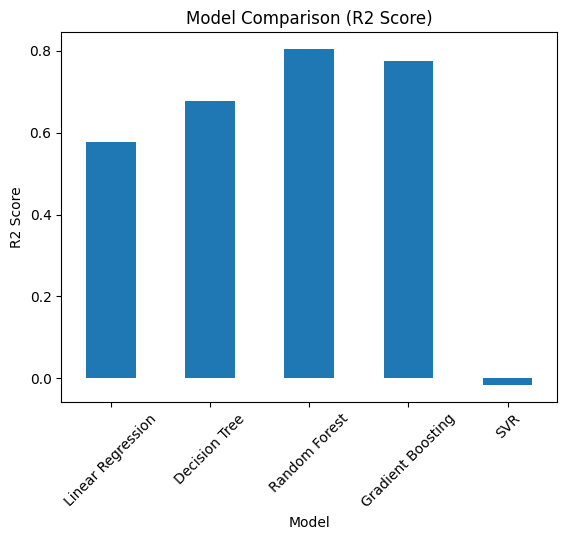

In [49]:
import matplotlib.pyplot as plt

results_df.set_index("Model")["R2 Score"].plot(kind="bar")
plt.title("Model Comparison (R2 Score)")
plt.ylabel("R2 Score")
plt.xticks(rotation=45)
plt.show()

In [50]:
best_model = results_df.loc[results_df["R2 Score"].idxmax()]
worst_model = results_df.loc[results_df["R2 Score"].idxmin()]

print("Best Model:\n", best_model)
print("\nWorst Model:\n", worst_model)

Best Model:
 Model       Random Forest
MSE              0.256776
MAE              0.328196
R2 Score         0.804049
Name: 2, dtype: object

Worst Model:
 Model            SVR
MSE         1.332212
MAE         0.860027
R2 Score   -0.016638
Name: 4, dtype: object


## Conclusion

In this assignment, multiple regression models were implemented and evaluated using the California Housing dataset.

Among all models, the best-performing model is Random forest  as it achieved the highest R² score, indicating better prediction accuracy.

The worst-performing model is Support vector machine, due to its lower R² score and higher error values.

Ensemble methods like Random Forest and Gradient Boosting performed better because they capture complex patterns and reduce overfitting.

Linear models performed comparatively lower as they assume a simple linear relationship between features and target.